In [1]:
import sys
import os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

sys.path.insert(0, "../code")
import dataset_utils as du

plt.style.use("/home/2649/repos/foxstyle/custom.mplstyle")

In [2]:
file_data = "/home/2649/repos/spec_res/data/forSNR/dataset.parquet"
df = pd.read_parquet(file_data)
arr = df["SNR"].to_numpy()
subtypes = df["SN Subtype"].unique()
maintypes = df["SN Maintype"].unique()

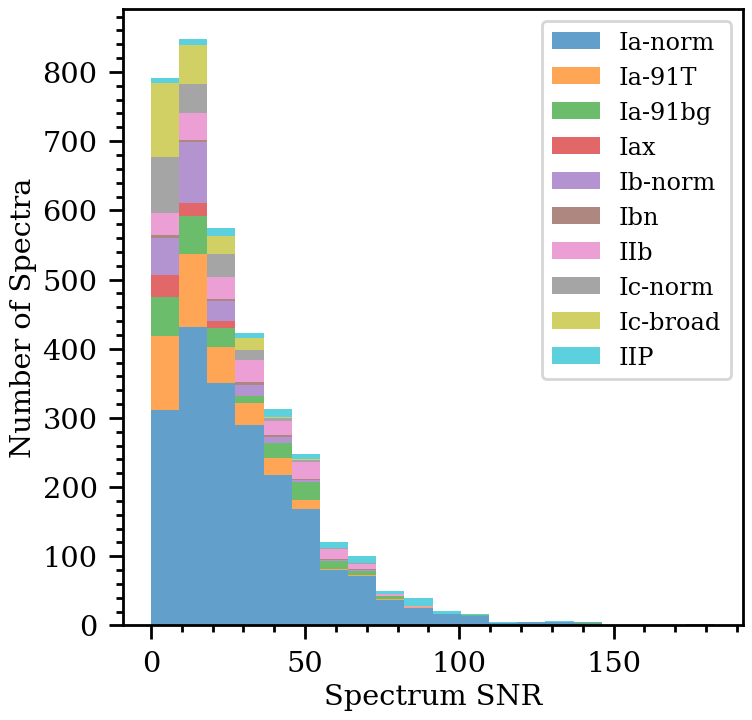

In [3]:
df_split_st = df.groupby(by=["SN Subtype"])[["SN Subtype", "SNR"]].apply(lambda x: x["SNR"].to_numpy())
fig, ax = plt.subplots()

snr_arr_st = [df_split_st[subtype] for subtype in subtypes]
ax.hist(snr_arr_st, stacked=True, bins=20, range=(0, arr.max()), label=subtypes, alpha=0.7)

ax.set_xlabel("Spectrum SNR")
ax.set_ylabel("Number of Spectra")

ax.legend(loc="upper right")
fig.show()

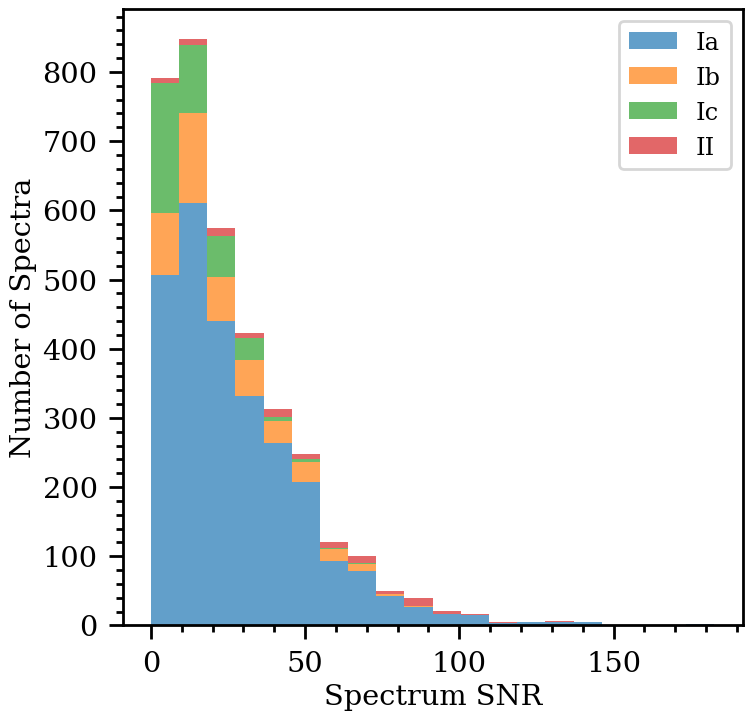

In [4]:
df_split_mt = df.groupby(by=["SN Maintype"])[["SN Maintype", "SNR"]].apply(lambda x: x["SNR"].to_numpy())
fig, ax = plt.subplots()

snr_arr_mt = [df_split_mt[maintype] for maintype in maintypes]
ax.hist(snr_arr_mt, stacked=True, bins=20, range=(0, arr.max()), label=maintypes, alpha=0.7)

ax.set_xlabel("Spectrum SNR")
ax.set_ylabel("Number of Spectra")

ax.legend(loc="upper right")
fig.show()

Maintype plot first, then subtype second, side by side.

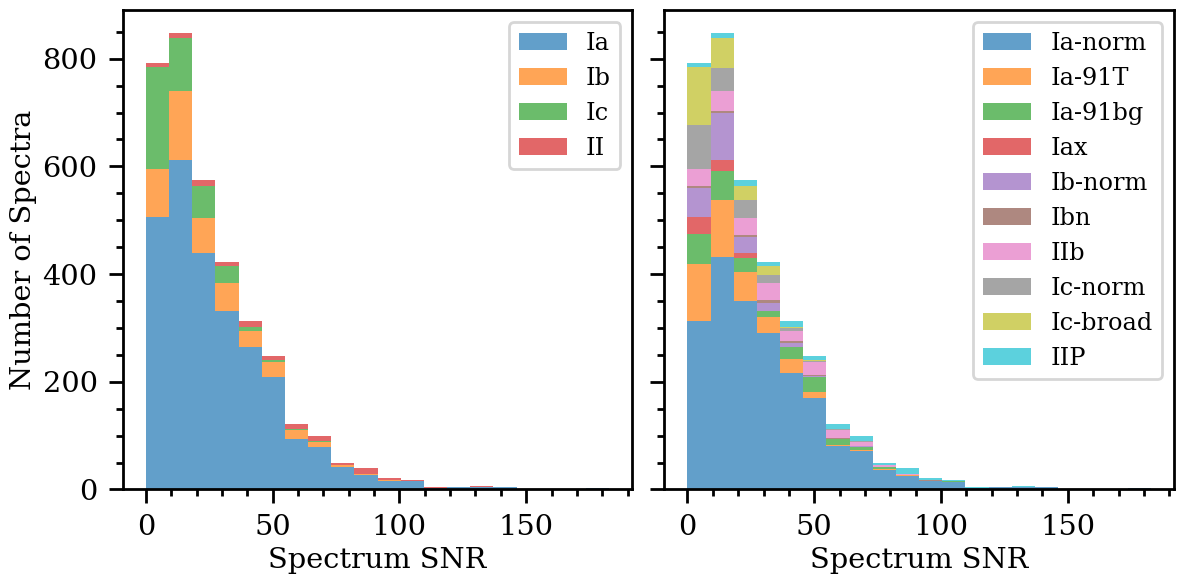

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, sharex=True, figsize=(12, 6))

axes[0].hist(snr_arr_mt, stacked=True, bins=20, range=(0, arr.max()), label=maintypes, alpha=0.7)
axes[1].hist(snr_arr_st, stacked=True, bins=20, range=(0, arr.max()), label=subtypes, alpha=0.7)

axes[0].set_xlabel("Spectrum SNR")
axes[1].set_xlabel("Spectrum SNR")
axes[0].set_ylabel("Number of Spectra")

axes[0].legend(loc="upper right")
axes[1].legend(loc="upper right")
fig.tight_layout()
fig.savefig("SNR_histogram.pdf")
fig.savefig("SNR_histogram.png")
fig.show()